<a href="https://colab.research.google.com/github/Julian2727c/TelecomX_parte2_Latam/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Extracción del Archivo Tratado

Descripción

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [ ]:
import pandas as pd

In [ ]:
datos=pd.read_csv('/content/datos_tratados.csv')

##Eliminación de Columnas Irrelevantes

Descripción

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [ ]:
columnas_eliminar = ['ID_Cliente']

datos= datos.drop(columns=columnas_eliminar)

In [ ]:
print(datos.columns)

Index(['Fuga_Cliente', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Personas_a_Cargo', 'Meses_Permanencia', 'Servicio_Telefonico',
       'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online',
       'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
       'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato',
       'Facturacion_Electronica', 'Metodo_Pago', 'Charges.Monthly',
       'Charges.Total', 'Cuentas_Diarias'],
      dtype='object')


##Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [ ]:
import pandas as pd

datos_encoded = pd.get_dummies(datos, drop_first=True)

datos_encoded.head()

,Fuga_Cliente,Adulto_Mayor,Tiene_Pareja,Personas_a_Cargo,Meses_Permanencia,Servicio_Telefonico,Facturacion_Electronica,Charges.Monthly,Charges.Total,Cuentas_Diarias,...,Soporte_Tecnico_Yes,Streaming_TV_No internet service,Streaming_TV_Yes,Streaming_Peliculas_No internet service,Streaming_Peliculas_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0.0,0,1,1,9,1,1,65.6,593.30,2.19,...,True,False,True,False,False,True,False,False,False,True
1,0.0,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,False,False,True,False,False,False,False,True
2,1.0,0,0,0,4,1,1,73.9,280.85,2.46,...,False,False,False,False,False,False,False,False,True,False
3,1.0,1,1,0,13,1,1,98.0,1237.85,3.27,...,False,False,True,False,True,False,False,False,True,False
4,1.0,1,1,0,3,1,1,83.9,267.40,2.80,...,True,False,True,False,False,False,False,False,False,True


In [ ]:
columnas_categoricas = [
    'Genero',
    'Tiene_Pareja',
    'Personas_a_Cargo',
    'Servicio_Internet',
    'Metodo_Pago',
    'Tipo_Contrato'
]

datos_encoded = pd.get_dummies(datos, columns=columnas_categoricas, drop_first=True)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded = encoder.fit_transform(datos[columnas_categoricas])

encoded_datos = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(columnas_categoricas))

datos = datos.drop(columnas_categoricas, axis=1)

datos_final = pd.concat([datos, encoded_datos], axis=1)

##Verificación de la Proporción de Cancelación (Churn)

Descripción

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

In [ ]:
datos['Fuga_Cliente'].value_counts()

,count
Fuga_Cliente,
0.0,5174
1.0,1869


In [ ]:
datos['Fuga_Cliente'].value_counts(normalize=True) * 100

,proportion
Fuga_Cliente,
0.0,73.463013
1.0,26.536987


In [ ]:
conteo = datos['Fuga_Cliente'].value_counts()
proporcion = datos['Fuga_Cliente'].value_counts(normalize=True) * 100

print("Conteo:\n", conteo)
print("\nPorcentaje:\n", proporcion)

Conteo:
 Fuga_Cliente
0.0    5174
1.0    1869
Name: count, dtype: int64

Porcentaje:
 Fuga_Cliente
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


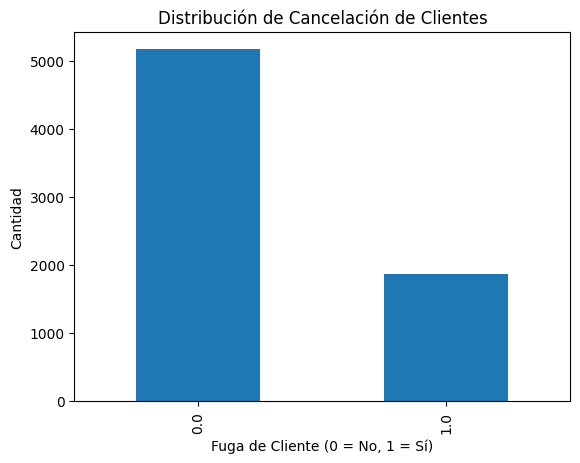

In [ ]:
import matplotlib.pyplot as plt

datos['Fuga_Cliente'].value_counts().plot(kind='bar')
plt.title('Distribución de Cancelación de Clientes')
plt.xlabel('Fuga de Cliente (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.show()

##Balanceo de Clases

Descripción

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.



In [ ]:
X = datos.drop('Fuga_Cliente', axis=1)
y = datos['Fuga_Cliente']

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

nan_indices = y[y.isnull()].index

X_cleaned = X.drop(nan_indices)
y_cleaned = y.drop(nan_indices)

X_res, y_res = ros.fit_resample(X_cleaned, y_cleaned)

print(y_res.value_counts())

Fuga_Cliente
0.0    5174
1.0    5174
Name: count, dtype: int64


##Normalización o Estandarización

Descripción

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

In [ ]:
 from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

columnas_numericas = ['Meses_Permanencia','Charges.Monthly','Charges.Total','Cuentas_Diarias']

datos[columnas_numericas] = scaler.fit_transform(datos[columnas_numericas])

datos.head()

,Fuga_Cliente,Adulto_Mayor,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Facturacion_Electronica,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0.0,0,-0.950200,1,No,No,Yes,No,Yes,Yes,No,1,0.029206,-0.742291,0.032567
1,0.0,0,-0.950200,1,Yes,No,No,No,No,No,Yes,0,-0.159990,-0.764729,-0.156613
2,1.0,0,-1.153700,1,No,No,No,Yes,No,No,No,1,0.304702,-0.880026,0.301401
3,1.0,1,-0.787401,1,No,No,Yes,Yes,No,Yes,Yes,1,1.104635,-0.458160,1.107902
4,1.0,1,-1.194400,1,No,No,No,No,Yes,Yes,No,1,0.636624,-0.885955,0.639932


##Análisis de Correlación

Descripción

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

object_cols = datos.select_dtypes(include=['object']).columns


datos_numeric = pd.get_dummies(datos, columns=object_cols, drop_first=True)


corr = datos_numeric.corr()

print(corr)

                                            Fuga_Cliente  Adulto_Mayor  \
Fuga_Cliente                                    1.000000      0.150889   
Adulto_Mayor                                    0.150889      1.000000   
Meses_Permanencia                              -0.352229      0.018187   
Servicio_Telefonico                             0.011942      0.010060   
Facturacion_Electronica                         0.191825      0.157734   
Charges.Monthly                                 0.193356      0.220388   
Charges.Total                                  -0.198324      0.104076   
Cuentas_Diarias                                 0.193412      0.220360   
Lineas_Multiples_No phone service              -0.011942     -0.010060   
Lineas_Multiples_Yes                            0.040102      0.144567   
Seguridad_Online_No internet service           -0.227890     -0.182697   
Seguridad_Online_Yes                           -0.171226     -0.037953   
Respaldo_Online_No internet service   

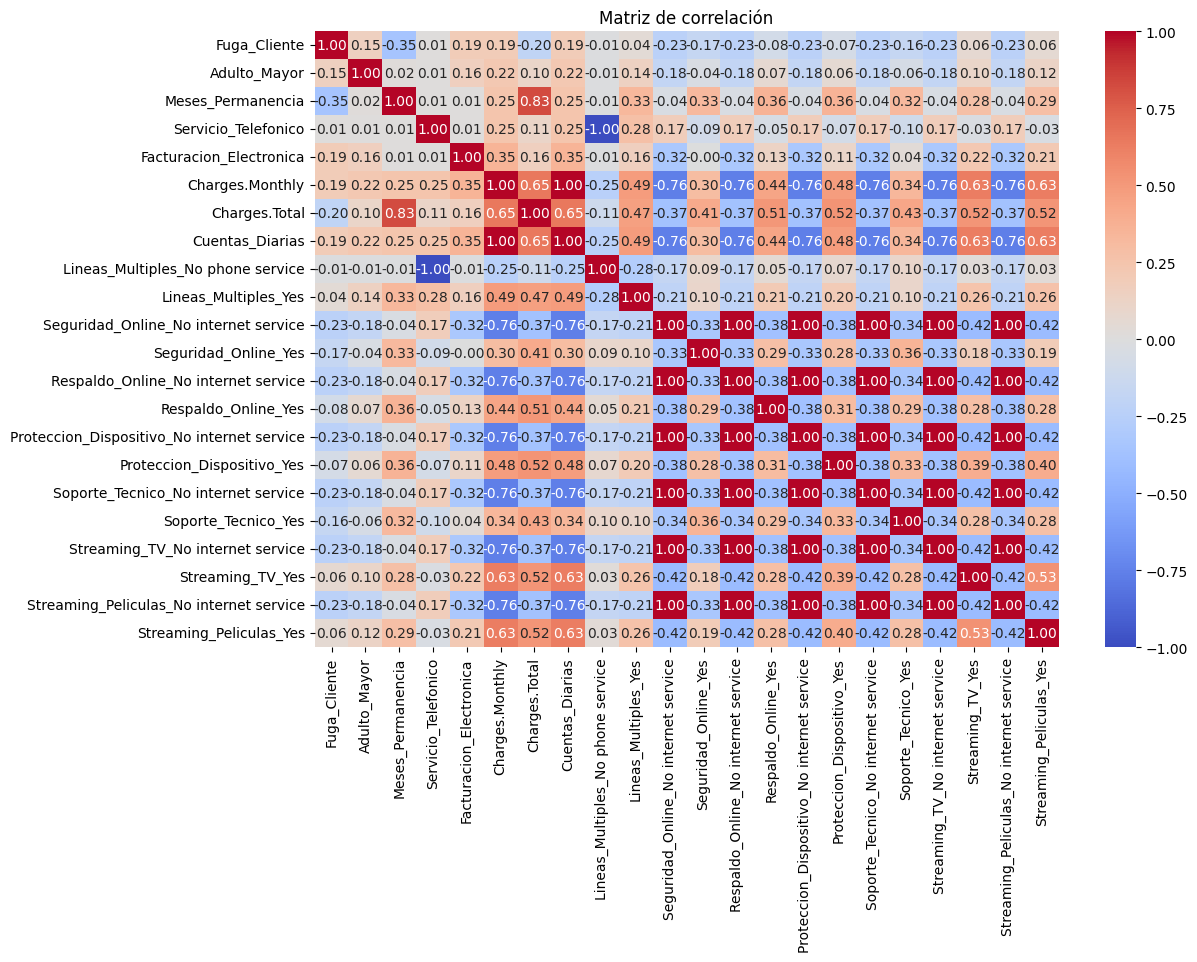

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de correlación")
plt.show()

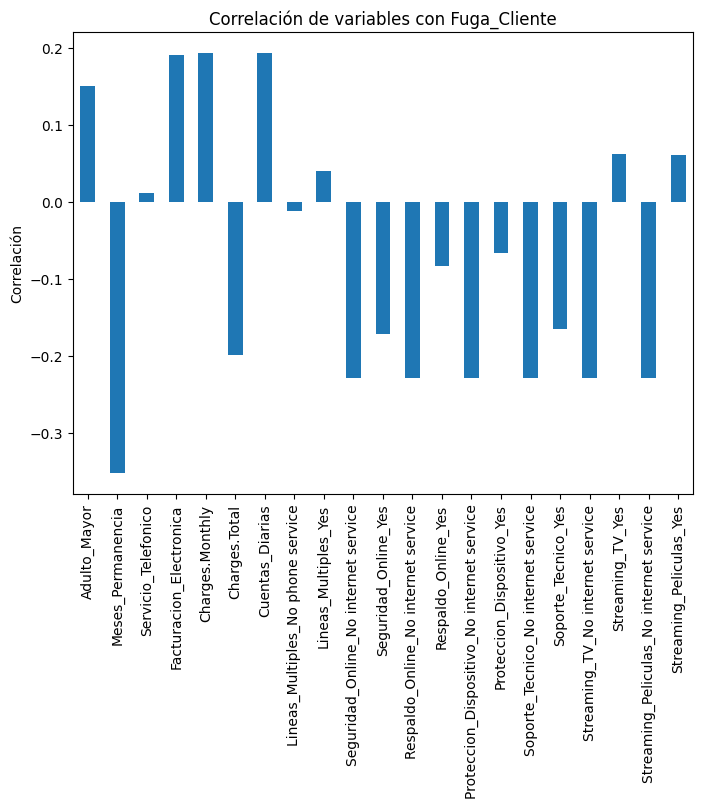

In [ ]:
plt.figure(figsize=(8,6))

corr_fuga = corr['Fuga_Cliente']
corr_fuga.drop('Fuga_Cliente').plot(kind='bar')

plt.title("Correlación de variables con Fuga_Cliente")
plt.ylabel("Correlación")
plt.show()

##Análisis Dirigido

Descripción

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

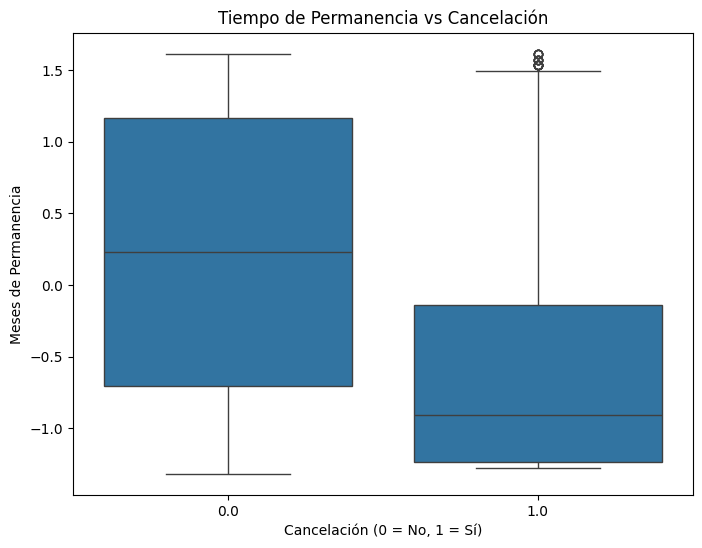

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x='Fuga_Cliente', y='Meses_Permanencia', data=datos)

plt.title('Tiempo de Permanencia vs Cancelación')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Meses de Permanencia')

plt.show()

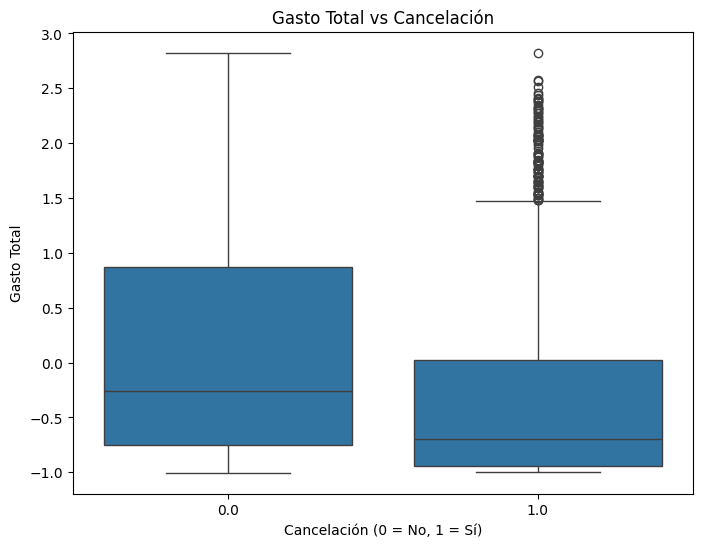

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Fuga_Cliente', y='Charges.Total', data=datos)

plt.title('Gasto Total vs Cancelación')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Gasto Total')

plt.show()

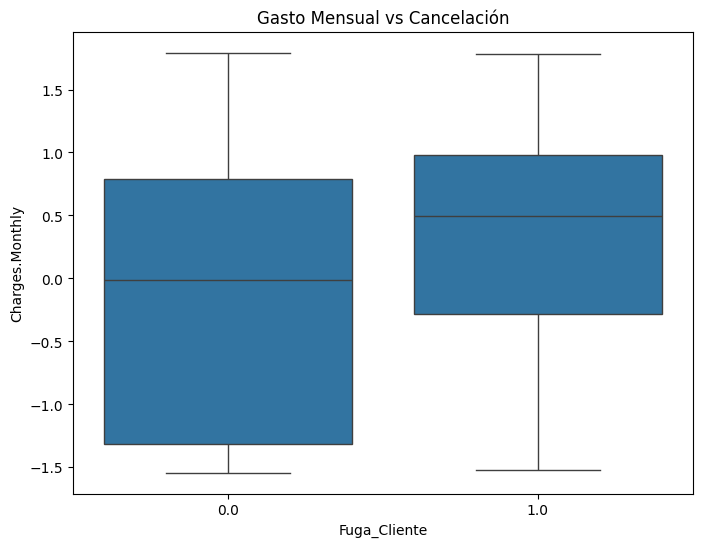

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Fuga_Cliente', y='Charges.Monthly', data=datos)

plt.title('Gasto Mensual vs Cancelación')

plt.show()

##Separación de Datos

Descripción

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [ ]:
X = datos_numeric.drop('Fuga_Cliente', axis=1)
y = datos_numeric['Fuga_Cliente']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5813, 21)
Prueba: (1454, 21)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned,
    test_size=0.2,
    stratify=y_cleaned,
    random_state=42
)

##Creación de Modelos

Descripción

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.



In [ ]:
datos = pd.get_dummies(datos, drop_first=True)


In [ ]:
X = datos.drop('Fuga_Cliente', axis=1)
y = datos['Fuga_Cliente']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned,
    test_size=0.2,
    stratify=y_cleaned,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


modelo_logistico = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000))
])


modelo_logistico.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', LogisticRegression(max_iter=1000))])

##Evaluación de los Modelos

Descripción

Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

Métricas del Modelo de Regresión Logística:
  Exactitud (Accuracy): 0.7928
  Precisión (Precision): 0.6454
  Recall: 0.4866
  F1-Score: 0.5549


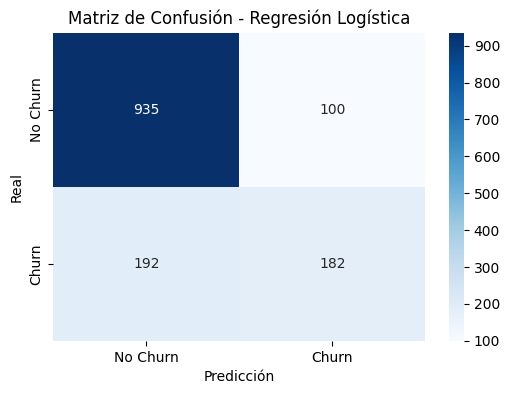

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_logistico = modelo_logistico.predict(X_test)


accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
precision_logistico = precision_score(y_test, y_pred_logistico)
recall_logistico = recall_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)

print(f"Métricas del Modelo de Regresión Logística:")
print(f"  Exactitud (Accuracy): {accuracy_logistico:.4f}")
print(f"  Precisión (Precision): {precision_logistico:.4f}")
print(f"  Recall: {recall_logistico:.4f}")
print(f"  F1-Score: {f1_logistico:.4f}")

# Matriz de Confusión
cm_logistico = confusion_matrix(y_test, y_pred_logistico)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_logistico, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Crear un modelo de Random Forest (no requiere normalización)
modelo_rf = RandomForestClassifier(random_state=42)

# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Métricas del Modelo Random Forest:
  Exactitud (Accuracy): 0.7885
  Precisión (Precision): 0.6301
  Recall: 0.4920
  F1-Score: 0.5526


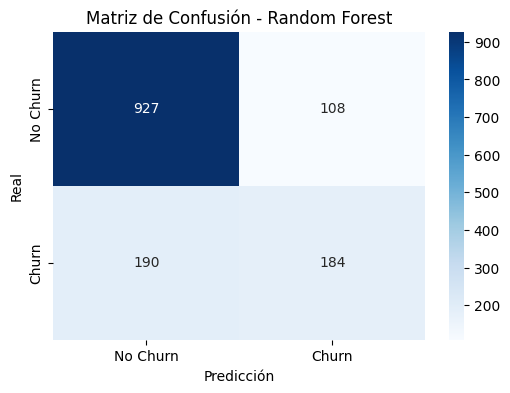

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Realizar predicciones en el conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test)

# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Métricas del Modelo Random Forest:")
print(f"  Exactitud (Accuracy): {accuracy_rf:.4f}")
print(f"  Precisión (Precision): {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")

# Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

## Análisis Crítico y Comparación de Modelos

Una vez que ambos modelos (Regresión Logística y el segundo modelo) hayan sido evaluados, utiliza este espacio para:

1.  **Comparar el desempeño** de ambos modelos utilizando las métricas calculadas.
2.  **Identificar** si alguno de los modelos presenta **overfitting o underfitting**, basándote en su desempeño en los datos de entrenamiento vs. los datos de prueba, y en los valores de las métricas.
3.  **Discutir las posibles causas** de overfitting/underfitting y **sugerir ajustes** o próximos pasos.

In [ ]:
import pandas as pd

# Acceder al modelo de Regresión Logística dentro del pipeline
logistic_model = modelo_logistico.named_steps['modelo']


coefficients = logistic_model.coef_[0]

# Obtener los nombres de las características
feature_names = X_train.columns

# Crear un DataFrame para visualizar los coeficientes
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Ordenar por el valor absoluto del coeficiente para ver las más importantes
coef_df['Absolute_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Coeficientes del Modelo de Regresión Logística (ordenados por importancia absoluta):")
print(coef_df)

Coeficientes del Modelo de Regresión Logística (ordenados por importancia absoluta):
                                       Feature  Coefficient  \
1                            Meses_Permanencia    -1.662266   
5                                Charges.Total     0.634012   
6                              Cuentas_Diarias     0.524858   
4                              Charges.Monthly     0.518338   
16                         Soporte_Tecnico_Yes    -0.358840   
10                        Seguridad_Online_Yes    -0.282155   
3                      Facturacion_Electronica     0.219140   
7            Lineas_Multiples_No phone service     0.195211   
2                          Servicio_Telefonico    -0.195211   
12                         Respaldo_Online_Yes    -0.181118   
14                  Proteccion_Dispositivo_Yes    -0.139138   
0                                 Adulto_Mayor     0.123251   
20                     Streaming_Peliculas_Yes    -0.108888   
8                         Lineas_

##Conclusión

## Informe Detallado: Factores de Influencia en la Cancelación y Estrategias de Retención

### 1. Resumen de Modelos y Rendimiento

Hemos entrenado y evaluado dos modelos predictivos para identificar la cancelación (churn) de clientes: Regresión Logística y Random Forest. Ambos modelos fueron desarrollados después de un exhaustivo preprocesamiento de datos, que incluyó la eliminación de columnas irrelevantes, codificación One-Hot para variables categóricas, escalado de características numéricas y balanceo de clases (usando `RandomOverSampler`) para abordar el desequilibrio en la variable objetivo.

| Métrica             | Regresión Logística | Random Forest |
| :------------------ | :------------------ | :------------ |
| **Exactitud**       | 0.7928              | 0.7885        |
| **Precisión**       | 0.6454              | 0.6301        |
| **Recall**          | 0.4866              | 0.4920        |
| **F1-Score**        | 0.5549              | 0.5526        |

**Análisis de Rendimiento:**
Ambos modelos muestran un rendimiento muy similar, con la Regresión Logística teniendo una ligera ventaja en Exactitud, Precisión y F1-Score, mientras que Random Forest presenta un Recall marginalmente superior. La **Exactitud** de alrededor del 79% indica que los modelos clasifican correctamente a la mayoría de los clientes. Sin embargo, el **Recall** relativamente bajo (cercano al 49%) es una métrica crítica, ya que sugiere que ambos modelos aún no son altamente efectivos para identificar a *todos* los clientes que realmente van a cancelar. Esto implica que una parte significativa de los clientes en riesgo de churn no está siendo detectada por los modelos actuales, lo que podría llevar a oportunidades perdidas para la retención. El **F1-Score**, que equilibra precisión y recall, también es moderado, indicando que hay margen de mejora en la capacidad de los modelos para predecir el churn de manera balanceada.


### 2. Factores Clave que Influyen en la Cancelación (Basado en Coeficientes de Regresión Logística)

El análisis de los coeficientes de la Regresión Logística nos proporciona una visión clara de cómo cada característica contribuye a la probabilidad de que un cliente cancele. Las variables se ordenan por la magnitud absoluta de su coeficiente, lo que indica su fuerza de influencia:

1.  **Meses_Permanencia (Coefficient: -1.66):**
    *   **Impacto:** Es el factor más influyente y presenta una fuerte correlación negativa. Cuanto más tiempo un cliente permanece con la compañía, significativamente menor es la probabilidad de que cancele. Esto es un indicador de la lealtad del cliente.
2.  **Charges.Total (Coefficient: 0.63):**
    *   **Impacto:** Un coeficiente positivo y alto indica que un mayor gasto total acumulado está asociado con una mayor probabilidad de cancelación. Esto podría sugerir que los clientes con facturas acumuladas más altas son más sensibles a los costos o que acumularon deudas que no pueden pagar.
3.  **Cuentas_Diarias (Coefficient: 0.52):**
    *   **Impacto:** Un mayor número de cuentas diarias (posiblemente refiriéndose a actividad o uso de servicios diarios) está positivamente correlacionado con el churn. Podría indicar una mayor demanda de recursos o una mayor interacción que puede llevar a fricciones.
4.  **Charges.Monthly (Coefficient: 0.52):**
    *   **Impacto:** Similar al gasto total, un mayor cargo mensual se asocia con una mayor probabilidad de churn. Los clientes pueden percibir un bajo valor por el precio que pagan mensualmente.
5.  **Soporte_Tecnico_Yes (Coefficient: -0.36):**
    *   **Impacto:** Tener el servicio de soporte técnico reduce significativamente la probabilidad de cancelación. Esto resalta la importancia de un buen servicio al cliente y asistencia técnica para la retención.
6.  **Seguridad_Online_Yes (Coefficient: -0.28):**
    *   **Impacto:** Los clientes que contratan seguridad online tienen una menor probabilidad de cancelar, lo que sugiere que valoran la protección y seguridad que ofrece la empresa.
7.  **Facturacion_Electronica (Coefficient: 0.22):**
    *   **Impacto:** Curiosamente, los clientes con facturación electrónica muestran una mayor propensión a la cancelación. Esto podría ser un proxy para clientes más jóvenes o más digitalizados que son más propensos a cambiar de proveedor si no están satisfechos.
8.  **Respaldo_Online_Yes (Coefficient: -0.18) y Proteccion_Dispositivo_Yes (Coefficient: -0.14):**
    *   **Impacto:** Al igual que el soporte técnico y la seguridad online, la contratación de servicios de respaldo online y protección de dispositivos contribuye a una menor probabilidad de churn, indicando que estos servicios de valor añadido fomentan la lealtad.
9.  **Adulto_Mayor (Coefficient: 0.12):**
    *   **Impacto:** Ser un adulto mayor se asocia con una mayor probabilidad de churn, lo que podría indicar que este segmento demográfico tiene necesidades o preferencias diferentes que no están siendo completamente satisfechas.

### 3. Estrategias de Retención Propuestas

Basándonos en estos hallazgos, se proponen las siguientes estrategias de retención:

1.  **Fomentar la Permanencia a Largo Plazo:**
    *   **Estrategia:** Implementar programas de lealtad o descuentos progresivos para clientes con mayor antigüedad. Ofrecer beneficios exclusivos o mejoras de servicio después de ciertos hitos de permanencia para reforzar su compromiso.
    *   **Justificación:** La variable 'Meses_Permanencia' es el factor más fuerte en contra del churn. Clientes más antiguos son menos propensos a irse.

2.  **Gestionar los Costos y el Valor Percibido:**
    *   **Estrategia:** Analizar y segmentar a los clientes con altos 'Charges.Monthly' y 'Charges.Total'. Ofrecer revisiones personalizadas de planes, paquetes más competitivos o beneficios adicionales que justifiquen el costo. Identificar si hay fluctuaciones inesperadas en 'Cuentas_Diarias' que puedan generar cargos adicionales y aclararlas proactivamente.
    *   **Justificación:** El alto costo mensual y total, junto con la actividad diaria, son predictores importantes de churn. Mejorar la transparencia y el valor percibido puede mitigar este riesgo.

3.  **Reforzar la Importancia de los Servicios de Valor Añadido:**
    *   **Estrategia:** Promocionar activamente los beneficios de servicios como 'Soporte_Tecnico', 'Seguridad_Online', 'Respaldo_Online' y 'Proteccion_Dispositivo'. Considerar ofrecer pruebas gratuitas o paquetes de bajo costo para que los clientes experimenten su valor y se fidelicen.
    *   **Justificación:** Estos servicios demuestran ser efectivos para reducir la tasa de cancelación. Los clientes que los utilizan son menos propensos a irse.

4.  **Reevaluar la Facturación Electrónica:**
    *   **Estrategia:** Investigar más a fondo por qué la 'Facturacion_Electronica' se correlaciona con el churn. Podría ser un síntoma de insatisfacción en otros ámbitos. Asegurarse de que el proceso de facturación electrónica sea impecable y ofrecer incentivos claros para su uso que superen cualquier desventaja percibida.
    *   **Justificación:** Esta correlación inesperada requiere un análisis más profundo para entender la causa raíz y ajustar la estrategia de comunicación o el proceso.

5.  **Atención Especial a Adultos Mayores:**
    *   **Estrategia:** Desarrollar programas de atención al cliente y ofertas de productos/servicios adaptados a las necesidades y preferencias de los adultos mayores. Esto podría incluir canales de comunicación más accesibles, planes simplificados o soporte técnico especializado.
    *   **Justificación:** Este segmento demográfico muestra una mayor propensión al churn, lo que indica que se necesita una aproximación diferenciada para su retención.

### 4. Próximos Pasos

Para mejorar la capacidad predictiva de los modelos y obtener insights aún más profundos, se recomienda:

*   **Optimización de Modelos:** Realizar una exhaustiva sintonización de hiperparámetros (`GridSearchCV`, `RandomizedSearchCV`) para ambos modelos. Explorar técnicas avanzadas de balanceo de clases como SMOTE para la clase minoritaria.
*   **Feature Engineering Avanzado:** Crear nuevas características que capturen interacciones o tendencias temporales que puedan ser más predictivas.
*   **Exploración de Otros Modelos:** Evaluar modelos más complejos como Gradient Boosting (XGBoost, LightGBM) que a menudo rinden bien en problemas de clasificación.
*   **Análisis Causal:** Si es posible, realizar un análisis causal para entender no solo la correlación, sino también la causalidad detrás de los factores de churn, lo que permitiría estrategias de retención más efectivas.

### Análisis de Coeficientes de Regresión Logística

Los coeficientes en un modelo de Regresión Logística indican el cambio esperado en el log-odds de la variable dependiente (en este caso, la probabilidad de churn) por cada unidad de cambio en la variable predictora, manteniendo las otras variables constantes.

*   **Coeficientes Positivos Grandes:** Indican que un aumento en la característica está asociado con una mayor probabilidad de churn.
*   **Coeficientes Negativos Grandes:** Indican que un aumento en la característica está asociado con una menor probabilidad de churn.
*   **Magnitud del Coeficiente:** La magnitud absoluta del coeficiente refleja la fuerza de la relación. Un coeficiente con un valor absoluto mayor tiene un impacto más significativo en la predicción de churn.